In [6]:
#Import libraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#implement pipeline in dataset
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OrdinalEncoder

# 6. Machine Learning Algorithm implement in pipeline and predict selling price
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest,chi2

In [7]:
#Load datset
df = pd.read_csv("/content/drive/MyDrive/dataset/CAR DETAILS FROM CAR DEKHO.csv")

In [8]:
#Check first 10 data
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner


In [9]:
#About dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [10]:
#Check null values
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [11]:
#Check duplicate values
df.duplicated().sum()

np.int64(763)

In [12]:
#REMOVE duplicated
df.drop_duplicates(inplace=True)

In [13]:
#Size of datset
df.shape

(3577, 8)

In [14]:
df['seller_type'].value_counts()

,count
seller_type,
Individual,2832
Dealer,712
Trustmark Dealer,33


In [15]:
df[df['year'] == 2007][['name','year']]

,name,year
0,Maruti 800 AC,2007
1,Maruti Wagon R LXI Minor,2007
5,Maruti Alto LX BSIII,2007
73,Tata Indigo Classic Dicor,2007
79,Honda Civic 1.8 V AT,2007
...,...,...
3923,Mahindra Renault Logan 1.5 DLX Diesel,2007
3977,Fiat Palio 1.2 Sport,2007
4146,Hyundai Verna CRDi SX,2007
4195,Maruti SX4 Zxi BSIII,2007


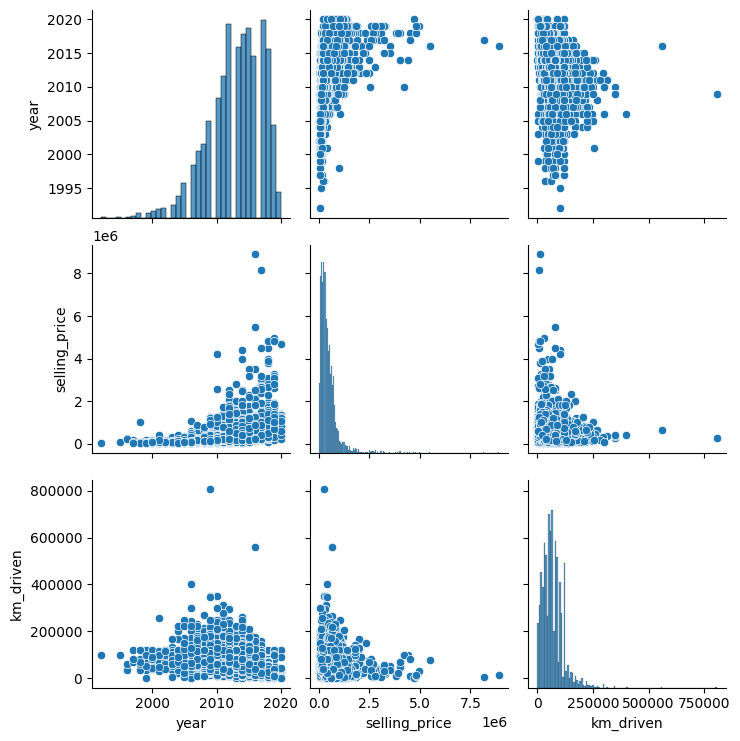

In [16]:
sns.pairplot(df)

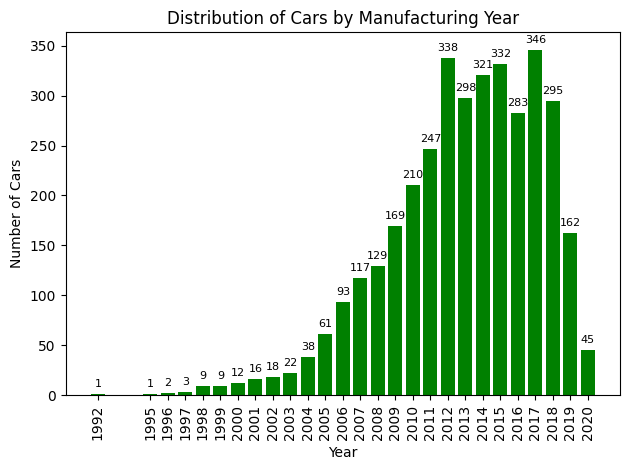

In [17]:
year_counts = df['year'].value_counts()
plt.bar(year_counts.index, year_counts.values, color='Green', align='center')
plt.xlabel('Year')
plt.ylabel('Number of Cars')
plt.title('Distribution of Cars by Manufacturing Year')
plt.xticks(year_counts.index, rotation=90) # Explicitly set all unique years as x-ticks

# Add count labels on top of each bar
for year, count in zip(year_counts.index, year_counts.values):
    plt.text(year, count + 5, str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
# Create a new 'brand' column from the 'name' column
#df['brand'] = df['name'].apply(lambda x: x.split(' ')[0])

In [19]:
# Make X input feature and y output feature
X = df.drop(columns=['selling_price','name'])
y = df['selling_price']

In [20]:
#Split data in training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
X_train.head()

,year,km_driven,fuel,seller_type,transmission,owner
2348,2014,135000,Diesel,Dealer,Manual,First Owner
1250,2017,20000,Petrol,Individual,Manual,Second Owner
955,2007,60000,Petrol,Individual,Manual,Fourth & Above Owner
4044,2014,64000,Petrol,Dealer,Manual,Second Owner
988,2018,68000,Petrol,Individual,Automatic,First Owner


In [22]:
numeric_features = X_train.select_dtypes(exclude='object').columns
categorical_features = X_train.select_dtypes(include='object').columns

print(f"Numeric Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")

Numeric Features: Index(['year', 'km_driven'], dtype='object')
Categorical Features: Index(['fuel', 'seller_type', 'transmission', 'owner'], dtype='object')


In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [24]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [25]:
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner',
       'Test Drive Car']]))
    ])

In [26]:
transformer = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features),
    ('ordinal', ordinal_transformer, ['owner'])
])

In [27]:
pipe = Pipeline(steps=[
    ('transformer', transformer),
    ('model', RandomForestRegressor(n_estimators=100,random_state=42))
])

In [28]:
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

Mean Squared Error: 177990707484.19287
Mean Absolute Error: 192936.23335865486
R-squared: 0.4474626579373686
